In [1]:
# install dependencies not included by Colab
# use pip3 to ensure compatibility w/ Google Deep Learning Images
!pip3 install -q pydicom
!pip3 install -q tqdm
!pip3 install -q imgaug

In [4]:
!pip install numpy==1.24.3

  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "C:\Users\MI Cimerak\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "C:\Users\MI Cimerak\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\MI Cimerak\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "C:\Users\MI Cimerak\AppData\Local\Programs\Pyt

In [5]:
import os
import sys

import random
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
import pydicom
from imgaug import augmenters as iaa
from tqdm import tqdm
import pandas as pd
import glob

In [6]:
# Install Kaggle API for download competition data
!pip3 install -q kaggle

In [7]:
# enter your Kaggle credentionals here
os.environ['raihanisucia']=""
os.environ['e26fd22343cab5e6cbfd7560086a53a7']=""

In [8]:
# Root directory of the project
ROOT_DIR = os.path.abspath('./lesson3-data')

# Directory to save logs and trained model
MODEL_DIR = os.path.join(ROOT_DIR, 'logs')

if not os.path.exists(ROOT_DIR):
    os.makedirs(ROOT_DIR)
os.chdir(ROOT_DIR)

In [15]:
import os
import json

# Pakai huruf 'r' di depan string agar Python tidak salah baca backslash
file_path = r'C:\Users\MI Cimerak\OneDrive\文档\kaggle.json'

# Cek apakah file ada
if os.path.exists(file_path):
    print("✅ File ditemukan. Membaca kaggle.json...")

    with open(file_path) as f:
        kaggle_token = json.load(f)

    print("✅ Berhasil membaca token:")
    print(kaggle_token)

else:
    print("❌ File kaggle.json TIDAK ditemukan. Cek lagi path-nya!")


✅ File ditemukan. Membaca kaggle.json...
✅ Berhasil membaca token:
{'username': 'raihanisucia', 'key': 'e26fd22343cab5e6cbfd7560086a53a7'}


In [17]:
import os
import shutil

# Path ke file kaggle.json
source = r'C:\Users\MI Cimerak\OneDrive\文档\kaggle.json'

# Path ke folder .kaggle di Windows user directory
destination_dir = os.path.join(os.path.expanduser('~'), '.kaggle')
destination_file = os.path.join(destination_dir, 'kaggle.json')

# Buat folder .kaggle kalau belum ada
os.makedirs(destination_dir, exist_ok=True)

# Salin file ke folder .kaggle
shutil.copy(source, destination_file)

# Ubah permission jadi hanya bisa dibaca pemilik (tidak wajib di Windows, tapi bisa ditiru)
os.chmod(destination_file, 0o600)

print(f"✅ kaggle.json berhasil disalin ke: {destination_file}")


✅ kaggle.json berhasil disalin ke: C:\Users\MI Cimerak\.kaggle\kaggle.json


In [18]:
!kaggle datasets list


ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jayaantanaath/student-habits-vs-academic-performance         Student Habits vs Academic Performance                   19512  2025-04-12 10:49:08.663000          17857        310  1.0              
fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid      Heart Attack Dataset                                     16250  2025-04-30 21:58:22.740000           3146         54  1.0              
adilshamim8/cost-of-international-education                  Cost of International Education                          18950  2025-05-07 15:41:53.213000           1905         31  1.0              
khushikyad001/i

In [24]:
pip install kaggle


In [28]:
import os

# Set environment variable untuk Kaggle API key
os.environ['KAGGLE_CONFIG_DIR'] = 'C:/Users/MI Cimerak/.kaggle'

# Cek apakah file bisa diakses
if os.path.exists(os.path.join(os.environ['KAGGLE_CONFIG_DIR'], 'kaggle.json')):
    print("Kaggle API key terdeteksi!")
else:
    print("File kaggle.json tidak ditemukan. Pastikan file sudah di tempat yang benar.")




Kaggle API key terdeteksi!


In [30]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = r'C:\Users\MI Cimerak\.kaggle'



In [32]:
!kaggle competitions files -c rsna-pneumonia-detection-challenge


Next Page Token = CfDJ8KvMat0eHzhGoPokVBGB7D0j9UjzJ-UVliv3Wch9rZCZze_uYzjOd06TunjpTsfzrvlXH2l_WP4Bbab5osh6_vE
name                                                                size  creationDate                
------------------------------------------------------------  ----------  --------------------------  
stage_2_test_images/0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm      125100  2019-12-11 23:45:23.530000  
stage_2_test_images/0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm      159200  2019-12-11 23:45:23.530000  
stage_2_test_images/000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm      172902  2019-12-11 23:45:23.530000  
stage_2_test_images/000e3a7d-c0ca-4349-bb26-5af2d8993c3d.dcm      161660  2019-12-11 23:45:23.530000  
stage_2_test_images/00100a24-854d-423d-a092-edcf6179e061.dcm      154692  2019-12-11 23:45:23.530000  
stage_2_test_images/0015597f-2d69-4bc7-b642-5b5e01534676.dcm      118254  2019-12-11 23:45:23.530000  
stage_2_test_images/001b0c51-c7b3-45c1-9c17-fa7594cab96e.dcm      

In [34]:
"stage_2_train_images.zip"
"stage_2_train_labels.csv"
"stage_2_test_images.zip"

...


Ellipsis

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.competition_download_files('rsna-pneumonia-detection-challenge', path='C:/Users/MI Cimerak/rsna-data')


In [2]:
api.competition_list_files('rsna-pneumonia-detection-challenge')


{"files": [{"ref": "", "name": "stage_2_test_images/0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm", "description": "", "totalBytes": 125100, "url": "", "creationDate": "2019-12-11T23:45:23.530Z"}, {"ref": "", "name": "stage_2_test_images/0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm", "description": "", "totalBytes": 159200, "url": "", "creationDate": "2019-12-11T23:45:23.530Z"}, {"ref": "", "name": "stage_2_test_images/000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm", "description": "", "totalBytes": 172902, "url": "", "creationDate": "2019-12-11T23:45:23.530Z"}, {"ref": "", "name": "stage_2_test_images/000e3a7d-c0ca-4349-bb26-5af2d8993c3d.dcm", "description": "", "totalBytes": 161660, "url": "", "creationDate": "2019-12-11T23:45:23.530Z"}, {"ref": "", "name": "stage_2_test_images/00100a24-854d-423d-a092-edcf6179e061.dcm", "description": "", "totalBytes": 154692, "url": "", "creationDate": "2019-12-11T23:45:23.530Z"}, {"ref": "", "name": "stage_2_test_images/0015597f-2d69-4bc7-b642-5b5e01534676.dcm", 

In [6]:
import os
print(os.listdir("C:/Users/MI Cimerak/rsna-data"))


['rsna-pneumonia-detection-challenge.zip']


In [8]:
import zipfile
import os

zip_path = "C:/Users/MI Cimerak/rsna-data/rsna-pneumonia-detection-challenge.zip"
extract_to = "C:/Users/MI Cimerak/rsna-data/"

# Pastikan file zip-nya ada dulu
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("File berhasil diekstrak!")
else:
    print("File ZIP tidak ditemukan. Cek path-nya.")


File berhasil diekstrak!


In [10]:
import os

folder_path = "C:/Users/MI Cimerak/rsna-data"

if os.path.exists(folder_path):
    files = os.listdir(folder_path)
    for file in files:
        print(file)
else:
    print("Folder tidak ditemukan. Pastikan path-nya benar.")


GCP Credits Request Link - RSNA.txt
rsna-pneumonia-detection-challenge.zip
stage_2_detailed_class_info.csv
stage_2_sample_submission.csv
stage_2_test_images
stage_2_train_images
stage_2_train_labels.csv


In [14]:
import os
import zipfile
import requests
from io import BytesIO

# Download ZIP dari GitHub
url = "https://github.com/matterport/Mask_RCNN/archive/refs/heads/master.zip"
response = requests.get(url)

# Ekstrak langsung
with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
    zip_ref.extractall("Mask_RCNN")

# Pindah ke direktori Mask_RCNN-master
os.chdir("Mask_RCNN/Mask_RCNN-master")

# Install
subprocess.run(["python", "setup.py", "install"])


CompletedProcess(args=['python', 'setup.py', 'install'], returncode=0)

In [18]:
import os
import zipfile
import requests
from io import BytesIO
import subprocess

# Download ZIP dari GitHub
url = "https://github.com/matterport/Mask_RCNN/archive/refs/heads/master.zip"
response = requests.get(url)

# Ekstrak ke folder Mask_RCNN
with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
    zip_ref.extractall("Mask_RCNN")

# Pindah ke folder hasil ekstraksi
os.chdir("Mask_RCNN/Mask_RCNN-master")

# Install
subprocess.run(["python", "setup.py", "install"])


CompletedProcess(args=['python', 'setup.py', 'install'], returncode=1)

In [21]:
import os

# Lihat direktori saat ini
print("Current working directory:", os.getcwd())

# Lihat folder apa saja yang ada
print("Available folders/files:", os.listdir())



Current working directory: C:\Users\MI Cimerak\MaskRCNNProject\Mask_RCNN\Mask_RCNN\Mask_RCNN-master
Available folders/files: ['.gitignore', 'assets', 'build', 'dist', 'images', 'LICENSE', 'MANIFEST.in', 'mask_rcnn.egg-info', 'mrcnn', 'README.md', 'requirements.txt', 'samples', 'setup.cfg', 'setup.py']


In [22]:
%cd "C:/Users/MI Cimerak/MaskRCNNProject/Mask_RCNN/Mask_RCNN-master"


C:\Users\MI Cimerak\MaskRCNNProject\Mask_RCNN\Mask_RCNN-master


C:\Users\MI Cimerak\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [1]:
import os, sys

ROOT_DIR = os.getcwd()  # atau path lain jika bukan di root
MASK_RCNN_DIR = os.path.join(ROOT_DIR, 'Mask_RCNN')
sys.path.append(MASK_RCNN_DIR)

In [11]:
train_dicom_dir = os.path.join(ROOT_DIR, 'stage_1_train_images')
test_dicom_dir = os.path.join(ROOT_DIR, 'stage_1_test_images')

In [12]:
def get_dicom_fps(dicom_dir):
    dicom_fps = glob.glob(dicom_dir+'/'+'*.dcm')
    return list(set(dicom_fps))

def parse_dataset(dicom_dir, anns):
    image_fps = get_dicom_fps(dicom_dir)
    image_annotations = {fp: [] for fp in image_fps}
    for index, row in anns.iterrows():
        fp = os.path.join(dicom_dir, row['patientId']+'.dcm')
        image_annotations[fp].append(row)
    return image_fps, image_annotations

In [13]:
# The following parameters have been selected to reduce running time for demonstration purposes
# These are not optimal

class DetectorConfig(Config):
    """Configuration for training pneumonia detection on the RSNA pneumonia dataset.
    Overrides values in the base Config class.
    """

    # Give the configuration a recognizable name
    NAME = 'pneumonia'

    # Train on 1 GPU and 8 images per GPU. We can put multiple images on each
    # GPU because the images are small. Batch size is 8 (GPUs * images/GPU).
    GPU_COUNT = 1
    IMAGES_PER_GPU = 8

    BACKBONE = 'resnet50'

    NUM_CLASSES = 2  # background + 1 pneumonia classes

    # Use small images for faster training. Set the limits of the small side
    # the large side, and that determines the image shape.
    IMAGE_MIN_DIM = 64
    IMAGE_MAX_DIM = 64

    RPN_ANCHOR_SCALES = (32, 64)

    TRAIN_ROIS_PER_IMAGE = 16

    MAX_GT_INSTANCES = 3

    DETECTION_MAX_INSTANCES = 3
    DETECTION_MIN_CONFIDENCE = 0.9
    DETECTION_NMS_THRESHOLD = 0.1

    RPN_TRAIN_ANCHORS_PER_IMAGE = 16
    STEPS_PER_EPOCH = 100
    TOP_DOWN_PYRAMID_SIZE = 32
    STEPS_PER_EPOCH = 100


config = DetectorConfig()
config.display()


Configurations:
BACKBONE                       resnet50
BACKBONE_STRIDES               [4, 8, 16, 32, 64]
BATCH_SIZE                     8
BBOX_STD_DEV                   [0.1 0.1 0.2 0.2]
COMPUTE_BACKBONE_SHAPE         None
DETECTION_MAX_INSTANCES        3
DETECTION_MIN_CONFIDENCE       0.9
DETECTION_NMS_THRESHOLD        0.1
FPN_CLASSIF_FC_LAYERS_SIZE     1024
GPU_COUNT                      1
GRADIENT_CLIP_NORM             5.0
IMAGES_PER_GPU                 8
IMAGE_CHANNEL_COUNT            3
IMAGE_MAX_DIM                  64
IMAGE_META_SIZE                14
IMAGE_MIN_DIM                  64
IMAGE_MIN_SCALE                0
IMAGE_RESIZE_MODE              square
IMAGE_SHAPE                    [64 64  3]
LEARNING_MOMENTUM              0.9
LEARNING_RATE                  0.001
LOSS_WEIGHTS                   {'rpn_class_loss': 1.0, 'rpn_bbox_loss': 1.0, 'mrcnn_class_loss': 1.0, 'mrcnn_bbox_loss': 1.0, 'mrcnn_mask_loss': 1.0}
MASK_POOL_SIZE                 14
MASK_SHAPE                     

In [15]:
class DetectorDataset(utils.Dataset):
    """Dataset class for training pneumonia detection on the RSNA pneumonia dataset.
    """

    def __init__(self, image_fps, image_annotations, orig_height, orig_width):
        super().__init__(self)

        # Add classes
        self.add_class('pneumonia', 1, 'Lung Opacity')

        # add images
        for i, fp in enumerate(image_fps):
            annotations = image_annotations[fp]
            self.add_image('pneumonia', image_id=i, path=fp,
                           annotations=annotations, orig_height=orig_height, orig_width=orig_width)

    def image_reference(self, image_id):
        info = self.image_info[image_id]
        return info['path']

    def load_image(self, image_id):
        info = self.image_info[image_id]
        fp = info['path']
        ds = pydicom.read_file(fp)
        image = ds.pixel_array
        # If grayscale. Convert to RGB for consistency.
        if len(image.shape) != 3 or image.shape[2] != 3:
            image = np.stack((image,) * 3, -1)
        return image

    def load_mask(self, image_id):
        info = self.image_info[image_id]
        annotations = info['annotations']
        count = len(annotations)
        if count == 0:
            mask = np.zeros((info['orig_height'], info['orig_width'], 1), dtype=np.uint8)
            class_ids = np.zeros((1,), dtype=np.int32)
        else:
            mask = np.zeros((info['orig_height'], info['orig_width'], count), dtype=np.uint8)
            class_ids = np.zeros((count,), dtype=np.int32)
            for i, a in enumerate(annotations):
                if a['Target'] == 1:
                    x = int(a['x'])
                    y = int(a['y'])
                    w = int(a['width'])
                    h = int(a['height'])
                    mask_instance = mask[:, :, i].copy()
                    cv2.rectangle(mask_instance, (x, y), (x+w, y+h), 255, -1)
                    mask[:, :, i] = mask_instance
                    class_ids[i] = 1
        return mask.astype(np.bool), class_ids.astype(np.int32)

In [18]:
# Ini sebaiknya diganti sesuai data asli kamu (DICOM + CSV annotations)
image_fps = ['sample.dcm']  # Ganti dengan path asli file DICOM
image_annotations = {
    'sample.dcm': [
        {'Target': 1, 'x': 100, 'y': 120, 'width': 80, 'height': 100},
        {'Target': 1, 'x': 200, 'y': 150, 'width': 50, 'height': 60}
    ]
}
orig_height, orig_width = 1024, 1024

In [19]:
# Inisialisasi dan load data
dataset = DetectorDataset(image_fps, image_annotations, orig_height, orig_width)
dataset.prepare()

In [25]:
import pandas as pd
import os

csv_path = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_labels.csv"
dicom_dir = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_images"


df = pd.read_csv(csv_path)
df_positive = df[df['Target'] == 1]  # ambil hanya yang ada opacity

# pilih satu contoh file
example_patient = df_positive['patientId'].iloc[0]
example_path = os.path.join(dicom_dir, f"{example_patient}.dcm")
annotations = df[df['patientId'] == example_patient].to_dict('records')

image_fps = [example_path]
image_annotations = {
    example_path: annotations
}
orig_height, orig_width = 1024, 1024


In [27]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import cv2
from mrcnn import utils

# Ganti path sesuai lokasi data kamu
csv_path = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_labels.csv"
dicom_dir = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_images"

In [28]:
# Load label data
df = pd.read_csv(csv_path)
df_positive = df[df['Target'] == 1]

In [29]:
# Ambil satu contoh file
example_patient = df_positive['patientId'].iloc[0]
example_path = os.path.join(dicom_dir, f"{example_patient}.dcm")
annotations = df[df['patientId'] == example_patient].to_dict('records')

image_fps = [example_path]
image_annotations = {example_path: annotations}
orig_height, orig_width = 1024, 1024

In [30]:
# Define class DetectorDataset (kode kamu sebelumnya)
class DetectorDataset(utils.Dataset):
    def __init__(self, image_fps, image_annotations, orig_height, orig_width):
        super().__init__(self)
        self.add_class('pneumonia', 1, 'Lung Opacity')
        for i, fp in enumerate(image_fps):
            annotations = image_annotations[fp]
            self.add_image('pneumonia', image_id=i, path=fp,
                           annotations=annotations, orig_height=orig_height, orig_width=orig_width)

    def image_reference(self, image_id):
        return self.image_info[image_id]['path']

    def load_image(self, image_id):
        info = self.image_info[image_id]
        ds = pydicom.dcmread(info['path'])
        image = ds.pixel_array
        if len(image.shape) != 3 or image.shape[2] != 3:
            image = np.stack((image,) * 3, -1)
        return image

    def load_mask(self, image_id):
        info = self.image_info[image_id]
        annotations = info['annotations']
        count = len(annotations)
        if count == 0:
            mask = np.zeros((info['orig_height'], info['orig_width'], 1), dtype=np.uint8)
            class_ids = np.zeros((1,), dtype=np.int32)
        else:
            mask = np.zeros((info['orig_height'], info['orig_width'], count), dtype=np.uint8)
            class_ids = np.zeros((count,), dtype=np.int32)
            for i, a in enumerate(annotations):
                if a['Target'] == 1:
                    x = int(a['x'])
                    y = int(a['y'])
                    w = int(a['width'])
                    h = int(a['height'])
                    mask[:, :, i] = cv2.rectangle(np.zeros((info['orig_height'], info['orig_width']), dtype=np.uint8),
                                                  (x, y), (x+w, y+h), 1, -1)
                    class_ids[i] = 1
        return mask.astype(np.bool_), class_ids.astype(np.int32)

In [31]:
# Buat objek dataset dan siapkan
dataset = DetectorDataset(image_fps, image_annotations, orig_height, orig_width)
dataset.prepare()

In [32]:
# Ambil gambar dan mask
image = dataset.load_image(0)
mask, class_ids = dataset.load_mask(0)

In [33]:
# Plot gambar dan mask overlay
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

(-0.5, 1023.5, 1023.5, -0.5)

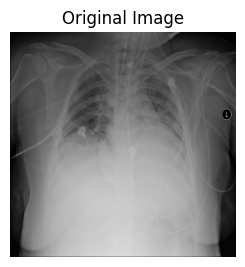

In [34]:
# Gambar asli
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

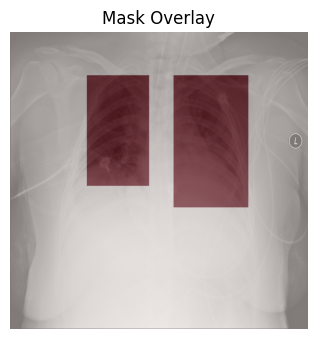

In [35]:
# Overlay mask
plt.subplot(1, 2, 2)
combined_mask = np.sum(mask.astype(np.uint8) * 255, axis=-1)
plt.imshow(image, cmap='gray')
plt.imshow(combined_mask, alpha=0.5, cmap='Reds')
plt.title("Mask Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

In [38]:
import os
import pandas as pd
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [39]:

# Path ke data (ubah sesuai dengan path data di sistem Anda)
csv_path = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_labels.csv"
dicom_dir = r"C:\Users\MI Cimerak\rsna-data\stage_2_train_images"

In [40]:
# Membaca data label
df = pd.read_csv(csv_path)
df_positive = df[df['Target'] == 1]  # Mengambil data yang memiliki pneumonia

In [41]:
# Pilih beberapa pasien untuk contoh (misalnya 5 gambar pertama)
example_patients = df_positive['patientId'].iloc[:5]  # Menampilkan 5 pasien pertama
image_fps = [os.path.join(dicom_dir, f"{patient}.dcm") for patient in example_patients]

In [42]:
# Ambil anotasi untuk pasien yang dipilih
image_annotations = {os.path.join(dicom_dir, f"{patient}.dcm"): df[df['patientId'] == patient].to_dict('records') 
                     for patient in example_patients}

orig_height, orig_width = 1024, 1024  # Ukuran asli gambar

In [43]:
# Kelas Dataset untuk memproses gambar dan mask
class DetectorDataset:
    def __init__(self, image_fps, image_annotations, orig_height, orig_width):
        self.image_fps = image_fps
        self.image_annotations = image_annotations
        self.orig_height = orig_height
        self.orig_width = orig_width

    def load_image(self, image_id):
        # Membaca file DICOM
        ds = pydicom.dcmread(self.image_fps[image_id])
        image = ds.pixel_array
        # Jika grayscale, konversi menjadi RGB untuk konsistensi
        if len(image.shape) != 3 or image.shape[2] != 3:
            image = np.stack((image,) * 3, -1)
        return image

    def load_mask(self, image_id):
        annotations = self.image_annotations[self.image_fps[image_id]]
        mask = np.zeros((self.orig_height, self.orig_width, len(annotations)), dtype=np.uint8)
        class_ids = np.zeros((len(annotations),), dtype=np.int32)

        for i, annotation in enumerate(annotations):
            if annotation['Target'] == 1:
                x = int(annotation['x'])
                y = int(annotation['y'])
                w = int(annotation['width'])
                h = int(annotation['height'])
                mask_instance = mask[:, :, i].copy()
                cv2.rectangle(mask_instance, (x, y), (x + w, y + h), 255, -1)
                mask[:, :, i] = mask_instance
                class_ids[i] = 1
        return mask.astype(bool), class_ids.astype(np.int32)  # Perbaikan disini

In [44]:
# Inisialisasi dataset
dataset = DetectorDataset(image_fps, image_annotations, orig_height, orig_width)

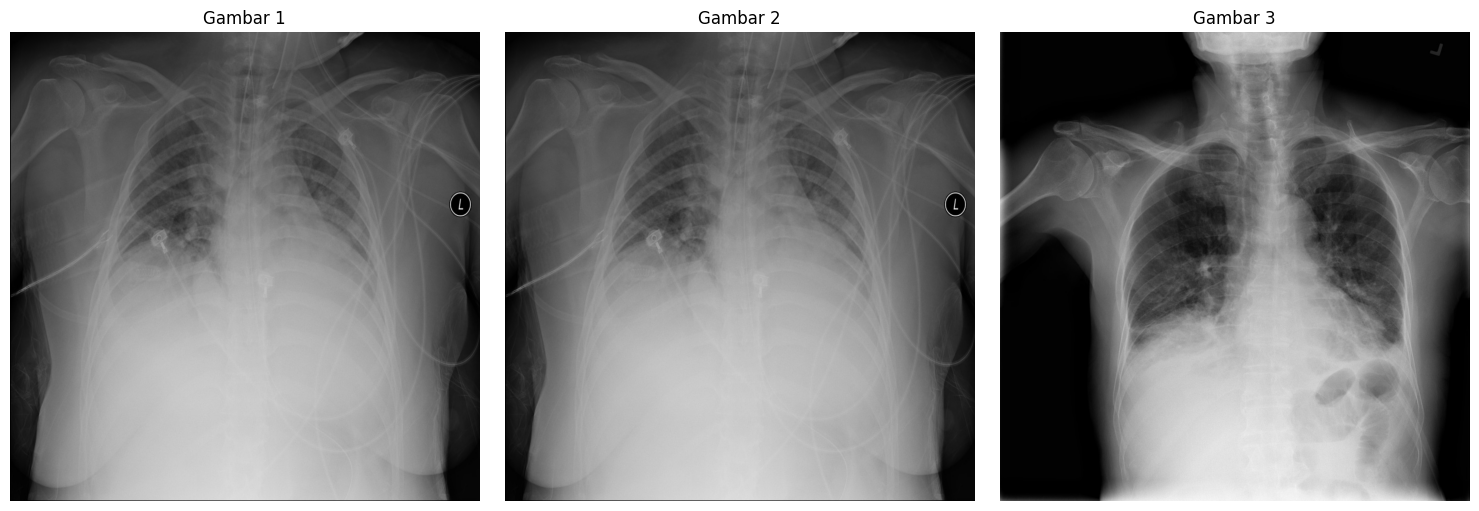

In [88]:


# Fungsi untuk menampilkan beberapa gambar asli
def display_multiple_images(dataset, num_images=3):
    num_images = min(num_images, len(dataset.image_fps))  # Pastikan tidak melebihi jumlah gambar yang ada
    plt.figure(figsize=(15, 5))  # Menyusun ukuran plot

    # Loop untuk menampilkan gambar asli dan mask overlay
    for i in range(num_images):
        image = dataset.load_image(i)  # Mengambil gambar
        mask, class_ids = dataset.load_mask(i)  # Mengambil mask
        
        # Menggabungkan mask menjadi satu gambar
        combined_mask = np.sum(mask.astype(np.uint8) * 255, axis=-1)

        # Gambar asli
        plt.subplot(1, num_images, i + 1)  # Subplot untuk setiap gambar
        plt.imshow(image, cmap='gray')  # Menampilkan gambar asli
        plt.axis('off')  # Menghilangkan sumbu
        plt.title(f'Gambar {i + 1}')

    plt.tight_layout()  # Menyusun layout agar tidak tumpang tindih
    plt.show()

# Menampilkan gambar sesuai jumlah yang tersedia
display_multiple_images(dataset, num_images=3)

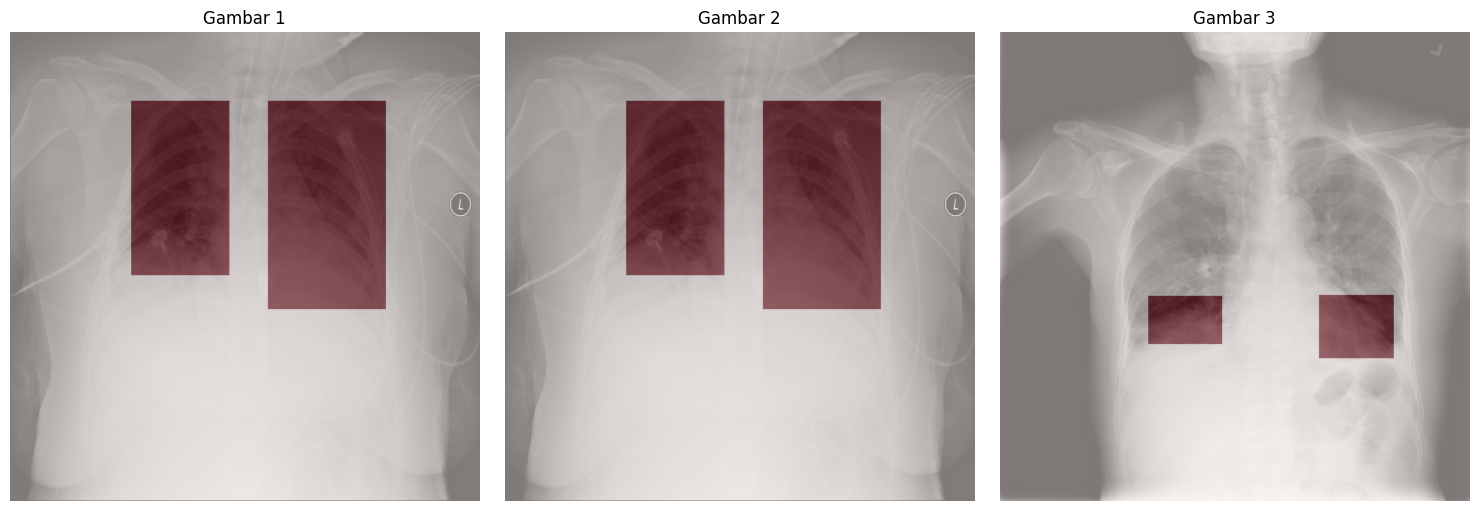

In [45]:
# Fungsi untuk menampilkan beberapa gambar
def display_multiple_images(dataset, num_images=3):
    num_images = min(num_images, len(dataset.image_fps))  # Pastikan tidak melebihi jumlah gambar yang ada
    plt.figure(figsize=(15, 5))  # Menyusun ukuran plot

    # Loop untuk menampilkan gambar dan mask overlay
    for i in range(num_images):
        image = dataset.load_image(i)  # Mengambil gambar
        mask, class_ids = dataset.load_mask(i)  # Mengambil mask
        
        # Menggabungkan mask menjadi satu gambar
        combined_mask = np.sum(mask.astype(np.uint8) * 255, axis=-1)

        # Gambar asli
        plt.subplot(1, num_images, i + 1)  # Subplot untuk setiap gambar
        plt.imshow(image, cmap='gray')  # Menampilkan gambar
        plt.imshow(combined_mask, alpha=0.5, cmap='Reds')  # Menambahkan overlay mask
        plt.axis('off')  # Menghilangkan sumbu
        plt.title(f'Gambar {i + 1}')

    plt.tight_layout()  # Menyusun layout agar tidak tumpang tindih
    plt.show()

# Menampilkan gambar sesuai jumlah yang tersedia
display_multiple_images(dataset, num_images=3)